## **1. Introduction**
In this notebook, we construct a subset of the WM-811K wafer map dataset to run experiments on class-conditional conformal prediction with data augmentation.



In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


##  **2. Library and utils**

In [2]:
# Load required libraries
import os
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
import matplotlib.cm as cm
from matplotlib import gridspec
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedShuffleSplit
import cv2 as cv
from PIL import Image

# Suppress warnings
warnings.filterwarnings("ignore")

# UTILS
# Extract first element from nested arrays
def extract_first_element(x):
    if isinstance(x, np.ndarray) and x.size > 0 and isinstance(x[0], (list, np.ndarray)) and len(x[0]) > 0:
        return x[0][0]
    return np.nan

# Generate image name from wafer ID
def generate_image_name(waferid):
    return f'wf_image_{waferid}.png'

# Plot single wafer
def plot_wafer(waferid, df, wfmap, save_dir=None):
    """
    Function to generate and save an image of the wafer map associated with a specific waferid.

    Parameters:
    - waferid: ID of the wafer to be visualized.
    - df: DataFrame containing the data.
    - wfmap: Column of the dataframe that contains the wafer map data.
    - save_dir: Directory to save the image (if specified).
    """
    # Extract the wafer map associated with the waferid
    wafer_map = df[df['wf_id'] == waferid][wfmap].values[0]

    # Reshape the wafer map into a 2D array 25x27
    #matrix = np.array(wafer_map).reshape(25, 27)
    matrix = np.array(wafer_map).reshape(df.waferMapDim[waferid])

    # Create the figure
    fig, ax = plt.subplots(figsize=(4, 4), dpi=101)
    ax.imshow(matrix, aspect='auto')

    # Remove borders, axes, and padding
    ax.set_axis_off()
    ax.set_frame_on(False)
    plt.subplots_adjust(left=0, right=1, top=1, bottom=0)

    # Save the image if a directory is specified
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)  # Create directory if it doesn't exist
        filename = f"wf_image_{waferid}.png"
        save_path = os.path.join(save_dir, filename)
        fig.savefig(save_path, dpi=101, bbox_inches='tight', pad_inches=0)
        plt.close(fig)  # Close figure to free memory
        #print(f"Image saved as {save_path}")
    else:
        plt.show()  # Show the image if no save directory is specified

# Plot the label distribution as a bar chart
def plot_label_distribution(df, label_col='labels', title='Label Distribution',
                            figsize=(6, 4), color_palette='Set2', save_path=None, show=True):

    counts = df[label_col].value_counts().sort_values(ascending=False)

    plt.figure(figsize=figsize)
    ax = plt.bar(counts.index.astype(str), counts.values,
                 color=sns.color_palette(color_palette, len(counts)))

    # Annotate each bar with its count
    for index, value in enumerate(counts.values):
        plt.text(index, value, f'{value}', ha='center', va='bottom', fontsize=8)

    plt.title(title, fontsize=13)
    plt.xlabel('Labels', fontsize=10)
    plt.ylabel('Counts', fontsize=10)
    plt.xticks(rotation=45, ha='right', fontsize=9)
    plt.yticks(fontsize=9)
    plt.grid(True, axis='both', linestyle='--', linewidth=0.5, alpha=0.8)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, format='pdf', bbox_inches='tight')

    if show:
        plt.show()

    plt.close()

#  Plot one wafer map per class from a given dataframe.
def plot_wafermaps_per_class(df, label_column='labels', map_column='waferMap',
                              dim_column='waferMapDim', label_names=None,
                              save_path=None, show=True):


    # Get all unique class labels
    unique_labels = sorted(df[label_column].unique())
    n_classes = len(unique_labels)

    # Create subplot grid
    fig, axs = plt.subplots(2, 4, figsize=(12, 6), dpi=100)
    axs = axs.flatten()

    for i, label in enumerate(unique_labels):
        # Get the first wafer corresponding to this class
        wafer_row = df[df[label_column] == label].iloc[0]

        # Reconstruct the 2D wafer map
        wafer_map = np.array(wafer_row[map_column]).reshape(wafer_row[dim_column])

        # Plot the map
        axs[i].imshow(wafer_map, aspect='auto', cmap='viridis')
        axs[i].set_axis_off()

        # Add the title with the class label name
        title = label_names.get(label, f'Class: {label}') if label_names else f'Class {label}'
        axs[i].set_title(title, fontsize=10)

    # Remove unused axes if fewer than 8 classes
    for j in range(n_classes, len(axs)):
        axs[j].axis('off')

    plt.tight_layout()

    # Save plot if path is provided
    if save_path:
        plt.savefig(save_path, format='pdf', bbox_inches='tight')

    # Show plot if requested
    if show:
        plt.show()

    plt.close()

def define_set(index):
    if index in train_df.index:
        return 'train'
    elif index in val_df.index:
        return 'val'
    elif index in test_df.index:
        return 'test'
    elif index in cal_df.index:
        return 'cal'
    else:
        return 0

## **3. Load dataset**

In [3]:
# Load dataset
path = "/content/drive/MyDrive/Conformal_Prediction_Research/Class_Conditional_CP_with_Data_Augmentation/WMDD_application/dataset/"
df = pd.read_pickle(path+"LSWMD.pkl")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 811457 entries, 0 to 811456
Data columns (total 6 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   waferMap        811457 non-null  object 
 1   dieSize         811457 non-null  float64
 2   lotName         811457 non-null  object 
 3   waferIndex      811457 non-null  float64
 4   trianTestLabel  811457 non-null  object 
 5   failureType     811457 non-null  object 
dtypes: float64(2), object(4)
memory usage: 37.1+ MB


## **4. Preprocessing and data analysis of WM-811K**

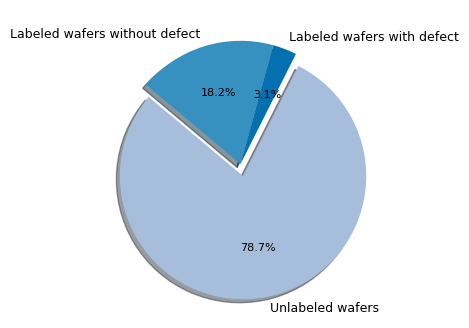

In [4]:
# Rename columns
df.rename(columns={'failureType': 'labels', 'trianTestLabel': 'trianTest', 'lotName': 'lotid'}, inplace=True)
df['failureNum'] = df['labels']
df['trainTestNum'] = df['trianTest']

# Map string labels to integers
failure_mapping = {'Center': 0, 'Donut': 1, 'Edge-Loc': 2, 'Edge-Ring': 3, 'Loc': 4,
                   'Random': 5, 'Scratch': 6, 'Near-full': 7, 'none': 8}
train_test_mapping = {'Training': 0, 'Test': 1}

df.replace({'failureNum': failure_mapping, 'trainTestNum': train_test_mapping}, inplace=True)

n_wafers = df.shape[0]
df_withlabel = df[(df['failureNum']>=0) & (df['failureNum']<=8)]
df_withlabel =df_withlabel.reset_index()
df_withpattern = df[(df['failureNum']>=0) & (df['failureNum']<=7)]
df_withpattern = df_withpattern.reset_index()
df_nonpattern = df[(df['failureNum']==8)]
df_withlabel.shape[0], df_withpattern.shape[0], df_nonpattern.shape[0]

#path_result= "/content/drive/MyDrive/Conformal_Prediction_Research/Class_Conditional_CP_with_Data_Augmentation/WMDD_application/results/"

fig, ax = plt.subplots(figsize=(4,4))

# Data for the pie chart
no_wafers = [n_wafers - df_withlabel.shape[0], df_withpattern.shape[0], df_nonpattern.shape[0]]
colors = ['#a6bddb', '#0570b0', '#3690c0']  # light blue -> dark -> medium
explode = (0.1, 0, 0)
labels = ['Unlabeled wafers', 'Labeled wafers with defect', 'Labeled wafers without defect']

# Create pie chart and capture label/percentage text objects
wedges, texts, autotexts = ax.pie(
    no_wafers, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
    shadow=True, startangle=140
)

# Set smaller font size for percentages
for autotext in autotexts:
    autotext.set_fontsize(8)

# Set smaller font size for legend labels
for text in texts:
    text.set_fontsize(9)

# Set chart title
#ax.set_title('Distribution of Labeled and Unlabeled Wafers in WM-811K Dataset')

# Save as PDF before showing
#plt.savefig(path_result + "wm_811k_plot.pdf", format='pdf', bbox_inches='tight')

plt.show()

## **5. WF-811K dataset with labels**

In [5]:
# Filter wafers with valid defect types (0–7)
df_pattern = df[df['failureNum'].between(0, 7)].drop(columns=['waferIndex']).reset_index(drop=True)

# Extract wafer map dimensions
df_pattern['waferMapDim'] = df_pattern['waferMap'].apply(lambda x: (np.size(x, 0), np.size(x, 1)))
df_pattern[['trianTest', 'labels']] = df_pattern[['trianTest', 'labels']].applymap(extract_first_element)

# Filter only common wafer map sizes (more than 200 samples)
common_sizes = df_pattern['waferMapDim'].value_counts()
valid_sizes = common_sizes[common_sizes > 200].index
df_filtered = df_pattern[df_pattern['waferMapDim'].isin(valid_sizes)].reset_index(drop=True)

print(f"Filtered dataset shape: {df_filtered.shape}")

Filtered dataset shape: (19947, 8)


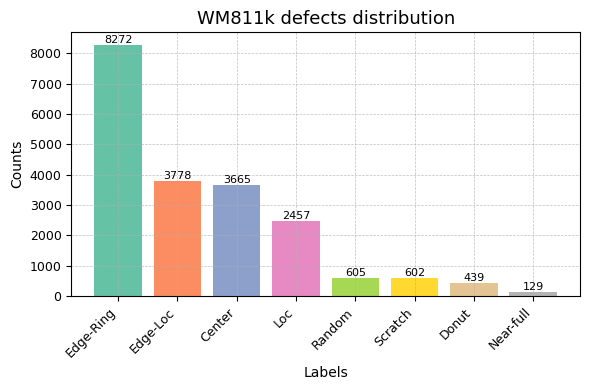

In [6]:
plot_label_distribution(df_filtered, label_col='labels', title='WM811k defects distribution', show=True)

## **6. Subset of WF-811K: downsampling overrepresented classes**

Balanced label distribution: {'Edge-Ring': 4136, 'Edge-Loc': 1889, 'Center': 1832, 'Loc': 1228, 'Random': 605, 'Scratch': 602, 'Donut': 439, 'Near-full': 129}
(10860, 9)


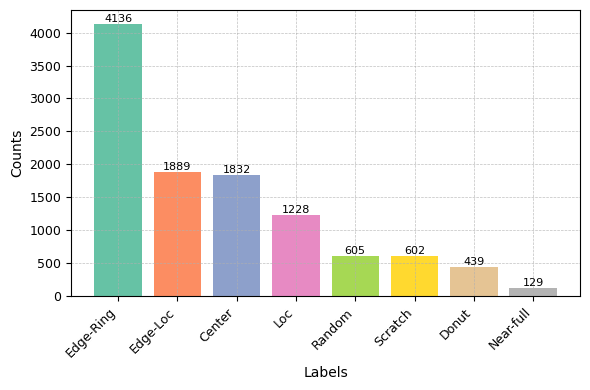

In [7]:
# Manually defined label counts (original)
original_counts = {
    'Edge-Ring': 8272, 'Edge-Loc': 3778, 'Center': 3665, 'Loc': 2457,
    'Random': 605, 'Scratch': 602, 'Donut': 439, 'Near-full': 129
}

# Reduce overrepresented classes by 50%
to_reduce = ['Edge-Ring', 'Edge-Loc', 'Center', 'Loc']
fixed = ['Random', 'Scratch', 'Donut', 'Near-full']
reduction_factor = 0.5

scaling = reduction_factor * sum(original_counts[l] for l in to_reduce) / sum(original_counts[l] for l in to_reduce)
balanced_counts = {l: int(np.round(original_counts[l] * scaling)) for l in to_reduce}
balanced_counts.update({l: original_counts[l] for l in fixed})

print("Balanced label distribution:", balanced_counts)

# Sample balanced subset
df_fixed = df_filtered[df_filtered['labels'].isin(fixed)]
df_sampled = pd.concat([
    df_filtered[df_filtered['labels'] == label].sample(n=balanced_counts[label], random_state=42)
    for label in to_reduce
])
df_reduced = pd.concat([df_fixed, df_sampled]).sample(frac=1, random_state=42).reset_index(drop=True)
df_reduced.insert(0, 'wf_id', df_reduced.index)
print(df_reduced.shape)

save_path = './wm811k_subset_label_distribution.pdf'#directory to save the graph

plot_label_distribution(df_reduced, label_col='labels', title='', save_path= save_path, show=True)



In [8]:
features= ['wf_id', 'dieSize', 'lotid', 'labels', 'image']
# Apply the function to create the 'images' column
df_reduced['image'] = df_reduced['wf_id'].apply(generate_image_name)


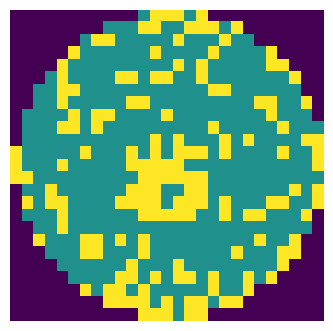

In [9]:

# Extract the waferMap associated with the given wafer ID
waferid = 2
wafer_map = df_reduced[df_reduced['wf_id'] == waferid]['waferMap'].values[0]

# Reshape the waferMap into a 2D array (25x27)
matrix = np.array(wafer_map).reshape(df_reduced.waferMapDim[waferid])

# Extract the label associated with the wafer ID
label = df_reduced[df_reduced['wf_id'] == waferid]['labels'].values[0]

# Create the figure for visualization
fig, ax = plt.subplots(figsize=(4, 4), dpi=101)
ax.imshow(matrix, aspect='auto')
ax.set_axis_off()  # Disable axes for a clean visualization


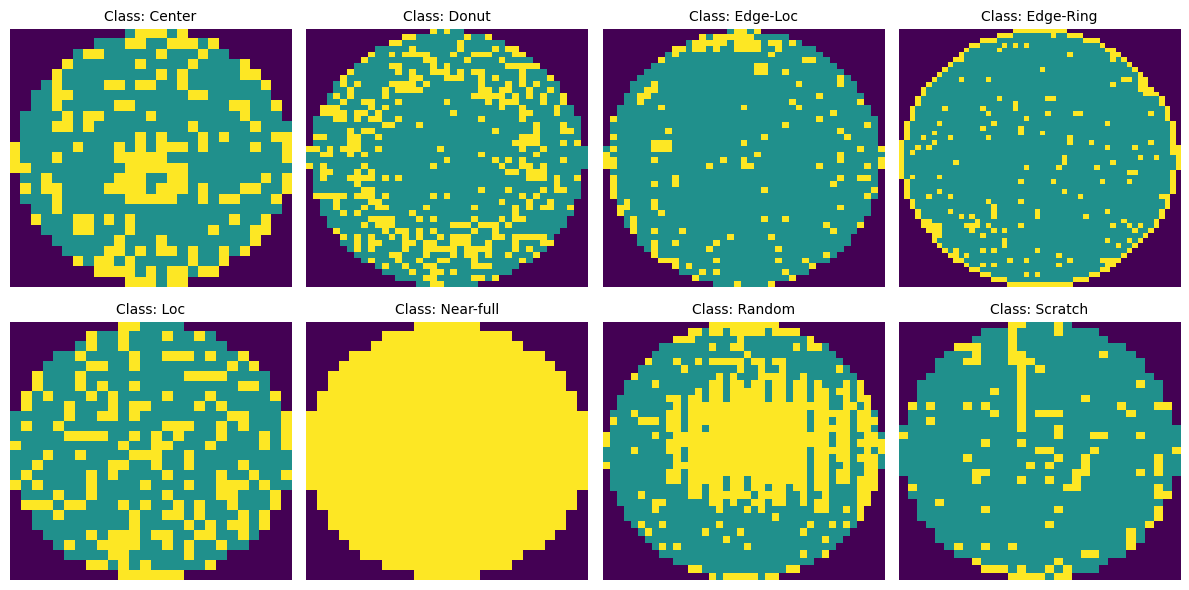

In [10]:
path_results = '/content/drive/MyDrive/Conformal_Prediction_Research/Class_Conditional_CP_with_Data_Augmentation/WMDD_application/results/'

label_dict = {
    0: 'Center',
    1: 'Donut',
    2: 'Edge-Loc',
    3: 'Edge-Ring',
    4: 'Loc',
    5: 'Random',
    6: 'Scratch',
    7: 'Near-full'
}
save_path = path_results+'wm811k_wafermap_per_class.pdf'
plot_wafermaps_per_class(df_reduced, label_names=label_dict, save_path=save_path, show=True)

In [11]:
# Define subfolder paths
base_path = '/content/drive/MyDrive/Conformal_Prediction_Research/Class_Conditional_CP_with_Data_Augmentation/WMDD_application/dataset/'
path_train = f'{base_path}/train'
path_val = f'{base_path}/val'
path_test = f'{base_path}/test'
path_cal = f'{base_path}/cal'

# Create subfolders if they do not exist.
# If the folders already exist, they will NOT be overwritten.
# This ensures that previously saved images are preserved if the script is interrupted and restarted.

Path(path_train).mkdir(parents=True, exist_ok=True)
Path(path_val).mkdir(parents=True, exist_ok=True)
Path(path_test).mkdir(parents=True, exist_ok=True)
Path(path_cal).mkdir(parents=True, exist_ok=True)

In [12]:
# First split: 80% training, 20% test
split_test = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split_test.split(df_reduced, df_reduced['labels']):
    train_temp = df_reduced.iloc[train_index].copy()  # 80% goes to temporary training set
    test_df = df_reduced.iloc[test_index].copy()      # 20% goes to test set

# Second split: 15% validation from the temporary training set
split_val = StratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
for train_index, val_index in split_val.split(train_temp, train_temp['labels']):
    train_temp2 = train_temp.iloc[train_index].copy()  # 85% of train_temp used for next training
    val_df = train_temp.iloc[val_index].copy()         # 15% of train_temp used for validation

# Third split: 20% calibration from the refined training set
split_cal = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, cal_index in split_cal.split(train_temp2, train_temp2['labels']):
    train_df = train_temp2.iloc[train_index].copy()  # 80% of train_temp2 used as final training set
    cal_df = train_temp2.iloc[cal_index].copy()      # 20% of train_temp2 used as calibration set

# Check the size of each split
print(f"Train: {len(train_df)}, Validation: {len(val_df)}, Calibration: {len(cal_df)}, Test: {len(test_df)}")

Train: 5907, Validation: 1304, Calibration: 1477, Test: 2172


In [13]:
df_reduced['set'] = df_reduced.index.map(define_set)

In [14]:
df_reduced['set'].value_counts()

,count
set,
train,5907
test,2172
cal,1477
val,1304


In [15]:
#Sanitary check
print((df_reduced[df_reduced['set']=='train'].index == train_df.index.sort_values()).all())
print((df_reduced[df_reduced['set']=='val'].index == val_df.index.sort_values()).all())
print((df_reduced[df_reduced['set']=='test'].index == test_df.index.sort_values()).all())
print((df_reduced[df_reduced['set']=='cal'].index == cal_df.index.sort_values()).all())

True
True
True
True


In [16]:
features.append('set')
df_reduced[features].to_csv(base_path+'/WM_811k_subset.csv')

In [17]:

# Saving train images
print('Saving train images')
wfd = list(train_df['wf_id'])
for col in tqdm(wfd):
     Construct the expected output filename
    filename = os.path.join(path_train, f"{col}.png")
     #Skip if the image already exists (checkpoint mechanism)
    if os.path.exists(filename):
        continue

    # Generate and save the wafer plot
    plot_wafer(col, df_reduced, wfmap='waferMap', save_dir=path_train)

# Saving test images
print('Saving test images')
wfd = list(test_df['wf_id'])
for col in tqdm(wfd):
    filename = os.path.join(path_test, f"{col}.png")
    if os.path.exists(filename):
        continue
    plot_wafer(col, df_reduced, wfmap='waferMap', save_dir=path_test)

# Saving validation images
print('Saving validation images')
wfd = list(val_df['wf_id'])
for col in tqdm(wfd):
    filename = os.path.join(path_val, f"{col}.png")
    if os.path.exists(filename):
        continue
    plot_wafer(col, df_reduced, wfmap='waferMap', save_dir=path_val)

# Saving calibration images
print('Saving calibration images')
wfd = list(cal_df['wf_id'])
for col in tqdm(wfd):
    filename = os.path.join(path_cal, f"{col}.png")
    if os.path.exists(filename):
        continue
    plot_wafer(col, df_reduced, wfmap='waferMap', save_dir=path_cal)


Saving validation images


  0%|          | 0/1304 [00:00<?, ?it/s]

Saving calibration images


  0%|          | 0/1477 [00:00<?, ?it/s]

In [18]:
'''
print('Saving train image')
wfd = list(train_df['wf_id'])
for col in tqdm(wfd):
   plot_wafer(col, df_reduced, wfmap='waferMap', save_dir=path_train)

print('Saving test image')
wfd = list(test_df['wf_id'])
for col in tqdm(wfd):
   plot_wafer(col, df_reduced, wfmap='waferMap', save_dir=path_test)

print('Saving val image')
wfd = list(val_df['wf_id'])
for col in tqdm(wfd):
   plot_wafer(col, df_reduced, wfmap='waferMap', save_dir=path_val)

print('Saving cal image')
wfd = list(cal_df['wf_id'])
for col in tqdm(wfd):
   plot_wafer(col, df_reduced, wfmap='waferMap', save_dir=path_cal)
'''

"\nprint('Saving train image')\nwfd = list(train_df['wf_id'])\nfor col in tqdm(wfd):\n   plot_wafer(col, df_reduced, wfmap='waferMap', save_dir=path_train)\n\nprint('Saving test image')\nwfd = list(test_df['wf_id'])\nfor col in tqdm(wfd):\n   plot_wafer(col, df_reduced, wfmap='waferMap', save_dir=path_test)\n\nprint('Saving val image')\nwfd = list(val_df['wf_id'])\nfor col in tqdm(wfd):\n   plot_wafer(col, df_reduced, wfmap='waferMap', save_dir=path_val)\n\nprint('Saving cal image')\nwfd = list(cal_df['wf_id'])\nfor col in tqdm(wfd):\n   plot_wafer(col, df_reduced, wfmap='waferMap', save_dir=path_cal)\n"

In [19]:
from pathlib import Path

path = Path('/content/drive/MyDrive/Conformal_Prediction_Research/Class_Conditional_CP_with_Data_Augmentation/WMDD_application/dataset/')
# Lista delle sotto-cartelle da esaminare
subfolders = ['train', 'val', 'test', 'cal']

# Ciclo sulle sotto-cartelle per contare i file
for folder_name in subfolders:
    folder_path = path / folder_name
    file_count = sum(1 for f in folder_path.iterdir() if f.is_file())
    print(f"Number of files in '{folder_name}': {file_count}")

Number of files in 'train': 5907
Number of files in 'val': 1304
Number of files in 'test': 2172
Number of files in 'cal': 1477
